In [169]:
import jax
import jax.numpy as jnp
import functions
import pybamm
import numpy as np

In [170]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")
# params_bat["Lower voltage cut-off [V]"] = -12.1
# params_bat["Upper voltage cut-off [V]"] = 44.2
# params_bat["Maximum concentration in negative electrode [mol.m-3]"] = 100e6
# params_bat["Maximum concentration in positive electrode [mol.m-3]"] = 100e6
# params_bat["Minimum concentration in negative electrode [mol.m-3]"] = 100e6
# params_bat["Minimum concentration in positive electrode [mol.m-3]"] = 100e6


# Hyperparameters
num_train = 22
num_test = 2

C = params_bat["Nominal cell capacity [A.h]"]
t_max = 10 * 1800
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [171]:
spm = pybamm.lithium_ion.SPM()
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]

def get_targets(I_samples, soc=0.5):
    set_targets = []
    set_c0 = []

    I_pruned = []

    fast_solver = pybamm.CasadiSolver(atol=1e-3, rtol=1e-3, mode="fast")
    
    for id, I_func in enumerate(I_samples):
        # Update parameter
        params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* I_func, pybamm.t)
        
        # Re-create the simulation with updated parameters
        sim = pybamm.Simulation(spm, parameter_values=params_bat, solver=fast_solver)
        
        sol = sim.solve(initial_soc=soc, t_eval=t)
        c0 = sol["Negative particle concentration"].entries[:,0,0]
        cn_target = sol["Negative particle concentration"].entries[:,0,:]

        if cn_target.shape[-1] != num_samples_I:
            continue
        else:
            I_pruned.append(I_func)
        
        set_targets.append(cn_target)
        set_c0.append(c0)

    
    return set_targets, set_c0, I_pruned


# def generate_data(key, num):
#     keys = jax.random.split(key, num)
#     func_I = []
#     for k in keys:
#         # Generate a random current function
#         I_func = functions.GaussianRFCurrent(k, C, t_max)
#         func_I.append(I_func(t))
#     return func_I

# def generate_data(key, num):
#     keys = jax.random.split(key, num)
#     train_I = []
#     for k in keys:
#         # Sample a random amplitude value for the triangle current
#         value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
#         I_func = functions.TriangleCurrent(value * C)
#         train_I.append(I_func(t))
#     return train_I

def generate_data(key, num_samples):
    keys = jax.random.split(key, num_samples)
    set_I = []
    for k in keys:
        # Generate a random constant current value between -1C and 1C
        rand_value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
        
        # Create a constant current function with that value
        I_func = functions.ConstantCurrent(rand_value*C)
        # Evaluate at times t and append
        set_I.append(I_func(t))
    return set_I

In [172]:
train_I = generate_data(key_train, num_train)
test_I = generate_data(key_test, num_test)
train_cn, train_c0, train_I = get_targets(train_I)
test_cn, test_c0, test_I = get_targets(test_I)

train_I = np.array(train_I)
test_I = np.array(test_I)
train_cn = np.array(train_cn)
test_cn = np.array(test_cn)
train_c0 = np.array(train_c0)
test_c0 = np.array(test_c0)

In [173]:
filename = ""
path = "data/spm/"
np.savez(path + "train/" + filename + ".npz", current=train_I, initial_concentration=train_c0, target_concentration=train_cn)
np.savez(path + "test/" + filename + ".npz", current=test_I, initial_concentration=test_c0, target_concentration=test_cn)

In [174]:
train_data = np.load(path + "train/" + filename + ".npz")
test_data = np.load(path + "test/" + filename + ".npz")

In [175]:
import matplotlib.pyplot as plt
plt.plot(train_data["current"][0])

IndexError: index 0 is out of bounds for axis 0 with size 0

In [168]:
train_data["current"].shape

(0,)

In [159]:
train_cn.shape

(7, 20, 75)

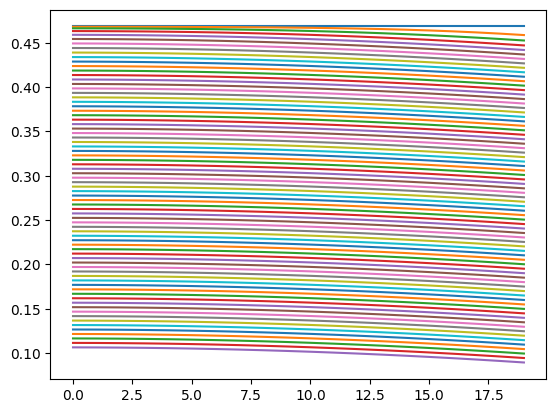

In [158]:
plt.plot(train_cn[0])